# Visão Clássica — Parte 1: Características e Classificadores

Detecção de anomalias em painéis solares (dataset *InfraredSolarModules*) por **visão
computacional clássica**. Esta primeira parte percorre, passo a passo:

1. Preparação dos dados e inspeção visual das imagens térmicas.
2. O *pipeline* heurístico inicial (limiar → morfologia → contornos).
3. A **extração de características** (descritores feitos à mão).
4. A **comparação de classificadores** (Random Forest, Gradient Boosting, SVM, XGBoost).
5. O **refinamento incremental** das características, medindo o ganho a cada grupo.

As Partes 2 (duas etapas e detector) e 3 (análise e otimização) estão em notebooks separados.

## 1. Setup e importações

Bibliotecas usadas: OpenCV e scikit-image (processamento de imagem), scikit-learn e XGBoost
(classificadores), além de pandas/numpy/matplotlib.

In [1]:
import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from skimage.feature import local_binary_pattern, hog
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from xgboost import XGBClassifier
from tqdm import tqdm

## 2. Download e leitura do dataset

O dataset é baixado e extraído automaticamente (caso ainda não exista). O arquivo
`module_metadata.json` relaciona cada imagem de 24x40 px à sua classe de anomalia. São
20.000 imagens em 12 classes, fortemente desbalanceadas (metade é `No-Anomaly`).

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "InfraredSolarModules"
DATASET_URL = "https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip"


def garantir_dataset():
    if (DATA_DIR / "module_metadata.json").exists():
        return
    zip_path = BASE_DIR / "2020-02-14_InfraredSolarModules.zip"
    if not zip_path.exists():
        print("Baixando dataset ...")
        urllib.request.urlretrieve(DATASET_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BASE_DIR)


garantir_dataset()
df = pd.DataFrame.from_dict(json.load(open(DATA_DIR / "module_metadata.json")), orient="index")
print("Distribuição das classes:")
print(df["anomaly_class"].value_counts())

Distribuição das classes:
anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
Name: count, dtype: int64


## 3. Inspeção visual das amostras

Visualizamos algumas imagens por classe. As imagens são térmicas (tons de cinza, 24x40):
defeitos com superaquecimento aparecem como regiões claras. Importante travar a escala em
`vmin=0, vmax=255` para não distorcer o contraste de módulos sem anomalia.

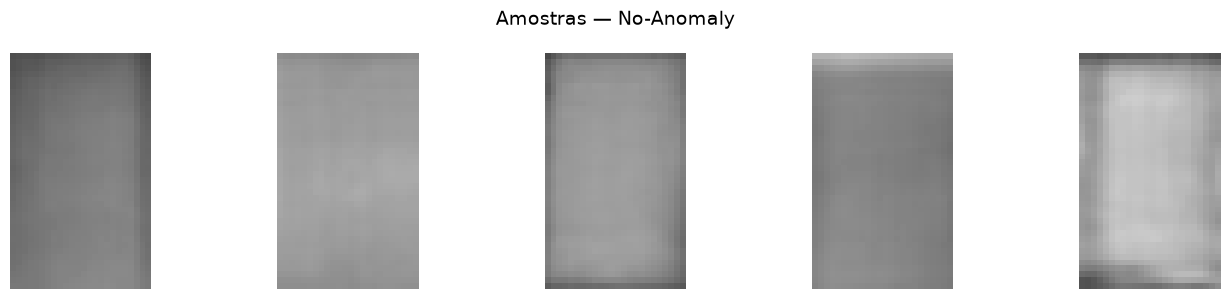

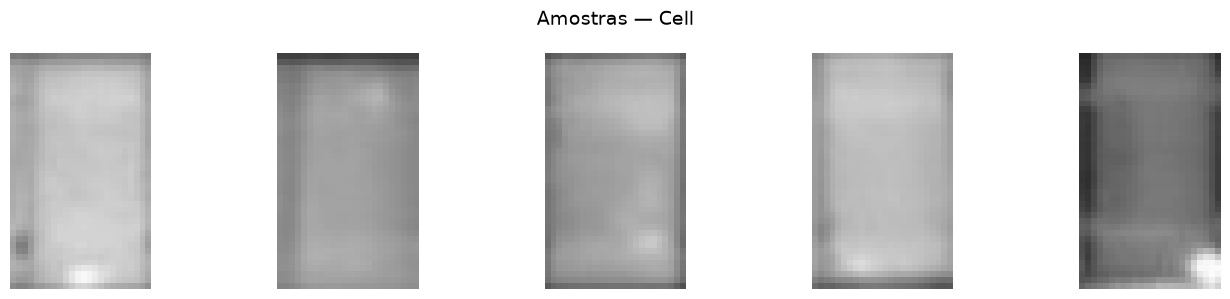

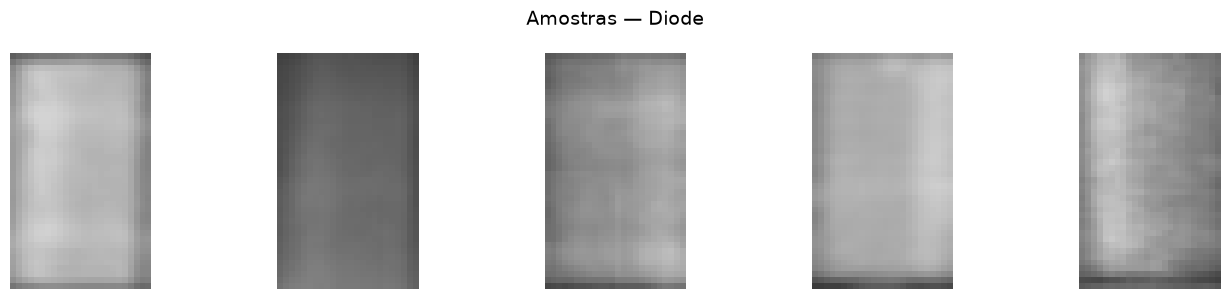

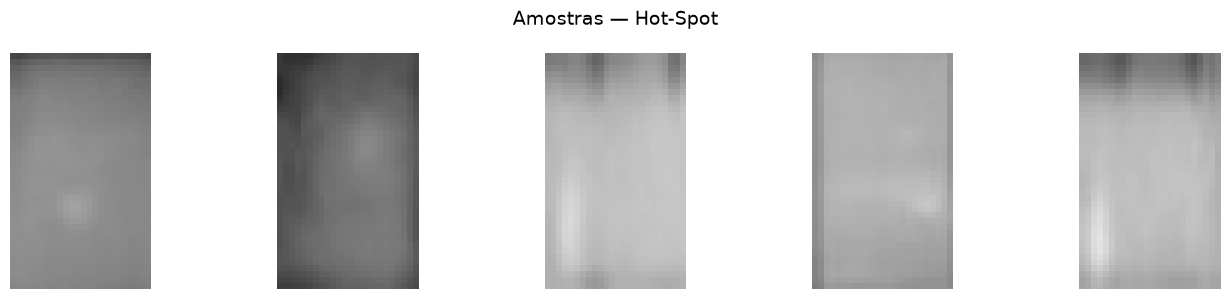

In [3]:
def visualizar_amostras(classe, n=5):
    amostras = df[df["anomaly_class"] == classe].sample(min(n, (df["anomaly_class"] == classe).sum()),
                                                        random_state=1)
    fig, axes = plt.subplots(1, n, figsize=(14, 3))
    fig.suptitle(f"Amostras — {classe}", fontsize=14)
    for ax, (_, r) in zip(np.atleast_1d(axes), amostras.iterrows()):
        img = cv2.imread(str(DATA_DIR / r["image_filepath"]), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for classe in ["No-Anomaly", "Cell", "Diode", "Hot-Spot"]:
    visualizar_amostras(classe)

## 4. Pipeline heurístico inicial

Primeira tentativa, puramente baseada em regras: para cada imagem, **limiariza** a região
quente, limpa com **morfologia** (abertura), extrai **contornos** e marca a maior mancha. É
eficaz para a classe *Cell* (ponto quente isolado), mas cobre poucas classes — o que motiva
a abordagem por características. Demonstramos em 3 exemplos.

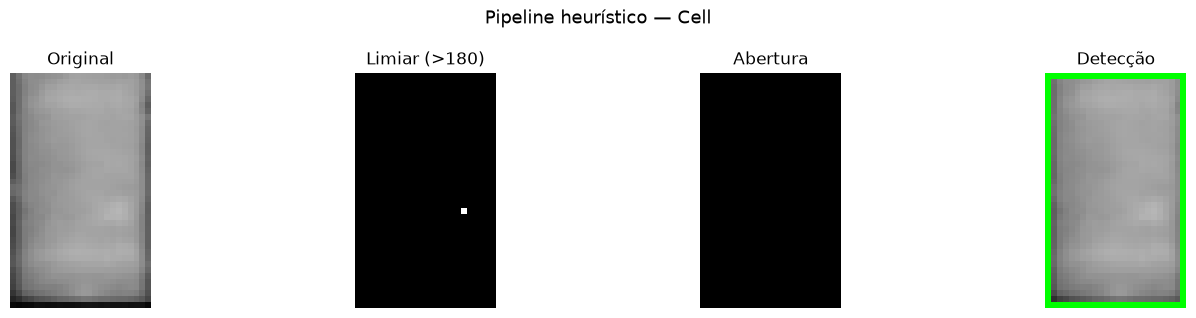

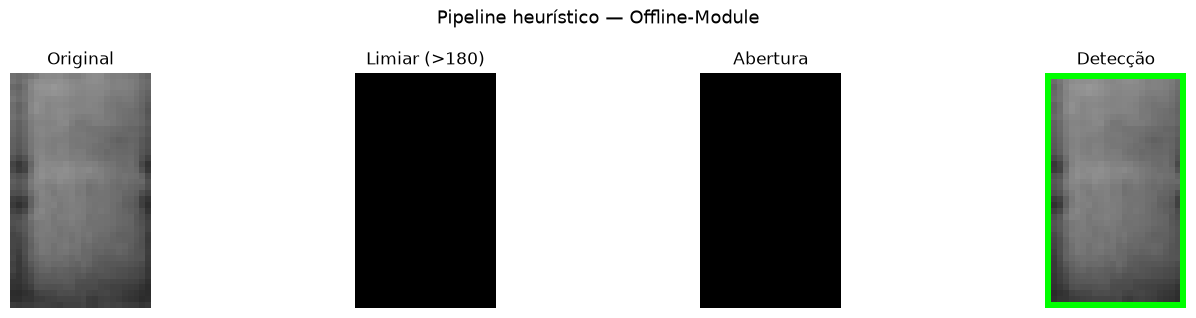

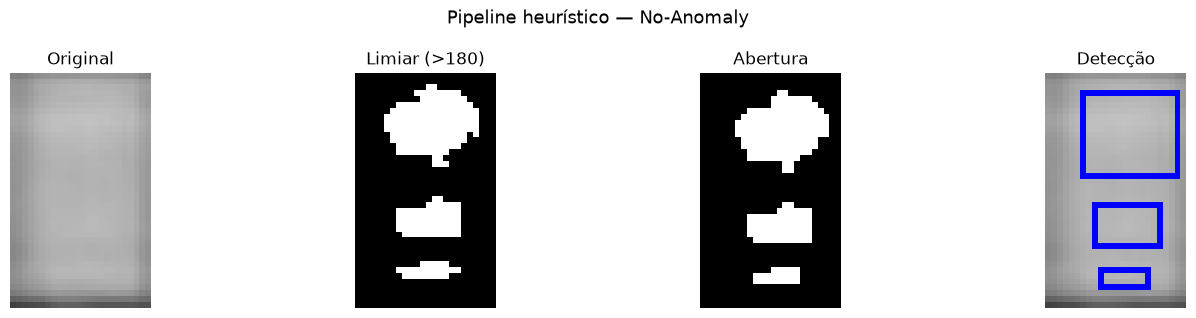

In [4]:
def pipeline_heuristico(img, rotulo):
    limiar = 180
    _, binaria = cv2.threshold(img, limiar, 255, cv2.THRESH_BINARY)
    kernel = np.ones((2, 2), np.uint8)
    aberta = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel)
    contornos, _ = cv2.findContours(aberta, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    resultado = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    achou = False
    for c in contornos:
        if cv2.contourArea(c) > 5:
            achou = True
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(resultado, (x, y), (x + w, y + h), (255, 0, 0), 1)
    if not achou:
        cv2.rectangle(resultado, (0, 0), (img.shape[1] - 1, img.shape[0] - 1), (0, 255, 0), 1)
    etapas = [img, binaria, aberta]
    titulos = ["Original", f"Limiar (>{limiar})", "Abertura"]
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
    fig.suptitle(f"Pipeline heurístico — {rotulo}", fontsize=13)
    for ax, im, tt in zip(axes, etapas, titulos):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(tt)
        ax.axis("off")
    axes[3].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    axes[3].set_title("Detecção")
    axes[3].axis("off")
    plt.tight_layout()
    plt.show()


for classe in ["Cell", "Offline-Module", "No-Anomaly"]:
    amostra = df[df["anomaly_class"] == classe].sample(1, random_state=7).iloc[0]
    img = cv2.imread(str(DATA_DIR / amostra["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    pipeline_heuristico(img, classe)

## 5. Extração de características

Em vez da imagem crua, descrevemos cada painel por um vetor de **características clássicas**.
Começamos por um conjunto **base de 25** e, mais adiante (seção 7), acrescentamos grupos extras
até **181** atributos. Os grupos são:

- **Base (25)**: estatísticas de intensidade; região quente (limiar de Otsu) — fração, nº de
  manchas, geometria da maior; cobertura por linha/coluna; região fria; bordas (Canny);
  textura (Sobel); simetria; histograma de intensidades.
- **Extras**: grade 3x3 + LBP (localização e textura), skewness/kurtosis, momentos de Hu
  (forma), Gabor + HOG (textura direcional e formas/trincas).

In [5]:
GABOR_KERNELS = [cv2.getGaborKernel((9, 9), 2.0, th, 4.0, 0.5, 0, ktype=cv2.CV_32F)
                 for th in np.deg2rad([0, 45, 90, 135])]


def extrair_features(img):
    img = img.astype(np.uint8)
    total = img.size
    f = {}
    # --- base (25 características) ---
    f["mean_int"] = float(img.mean())
    f["std_int"] = float(img.std())
    f["max_int"] = float(img.max())
    f["min_int"] = float(img.min())
    f["p90_int"] = float(np.percentile(img, 90))
    otsu_t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, hot = cv2.threshold(img, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
    hot = cv2.morphologyEx(hot, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    f["hot_fraction"] = float(hot.sum() / 255) / total
    contornos, _ = cv2.findContours(hot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = [c for c in contornos if cv2.contourArea(c) >= 2]
    f["num_blobs"] = float(len(blobs))
    if blobs:
        maior = max(blobs, key=cv2.contourArea)
        area = cv2.contourArea(maior)
        x, y, w, h = cv2.boundingRect(maior)
        f["largest_area"] = float(area)
        f["largest_extent"] = float(area / (w * h)) if w * h > 0 else 0.0
        f["largest_aspect"] = float(w / h) if h > 0 else 0.0
    else:
        f["largest_area"] = f["largest_extent"] = f["largest_aspect"] = 0.0
    f["row_cov"] = float((hot.sum(axis=1) > 0).mean())
    f["col_cov"] = float((hot.sum(axis=0) > 0).mean())
    f["dark_fraction"] = float((img < (img.mean() - img.std())).mean())
    f["edge_density"] = float((cv2.Canny(img, 50, 150) > 0).mean())
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    f["grad_mean"] = float(np.sqrt(gx ** 2 + gy ** 2).mean())
    imgf = img.astype(np.float32)
    f["sym_lr"] = float(np.abs(imgf - np.fliplr(imgf)).mean())
    f["sym_tb"] = float(np.abs(imgf - np.flipud(imgf)).mean())
    hist = cv2.calcHist([img], [0], None, [8], [0, 256]).flatten()
    hist = hist / hist.sum()
    for i, hv in enumerate(hist):
        f[f"hist{i}"] = float(hv)
    # --- grupos adicionais ---
    f["skew_int"] = float(skew(imgf.ravel())) if img.std() > 0 else 0.0
    f["kurt_int"] = float(kurtosis(imgf.ravel())) if img.std() > 0 else 0.0
    hu = np.zeros(7)
    if blobs:
        mk = np.zeros_like(img)
        cv2.drawContours(mk, [maior], -1, 255, -1)
        huv = cv2.HuMoments(cv2.moments(mk)).flatten()
        hu = np.array([-np.sign(v) * np.log10(abs(v) + 1e-30) for v in huv])
    for i in range(7):
        f[f"hu_{i}"] = float(hu[i])
    hh, ww = img.shape
    hs, ws = hh // 3, ww // 3
    for i in range(3):
        for j in range(3):
            y0, y1 = i * hs, (hh if i == 2 else (i + 1) * hs)
            x0, x1 = j * ws, (ww if j == 2 else (j + 1) * ws)
            f[f"grid_{i}{j}"] = float(img[y0:y1, x0:x1].mean())
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    lh, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    for k, v in enumerate(lh):
        f[f"lbp_{k}"] = float(v)
    for i, kern in enumerate(GABOR_KERNELS):
        resp = cv2.filter2D(imgf, cv2.CV_32F, kern)
        f[f"gabor{i}_mean"] = float(resp.mean())
        f[f"gabor{i}_std"] = float(resp.std())
    for k, v in enumerate(hog(imgf, orientations=8, pixels_per_cell=(8, 8),
                              cells_per_block=(1, 1), feature_vector=True, channel_axis=None)):
        f[f"hog_{k}"] = float(v)
    return f


BASE_FEATS = ["mean_int", "std_int", "max_int", "min_int", "p90_int", "hot_fraction",
              "num_blobs", "largest_area", "largest_extent", "largest_aspect", "row_cov",
              "col_cov", "dark_fraction", "edge_density", "grad_mean", "sym_lr", "sym_tb",
              "hist0", "hist1", "hist2", "hist3", "hist4", "hist5", "hist6", "hist7"]

### Ilustração das características em uma imagem

Para tornar concreto, mostramos numa amostra a região quente (máscara de Otsu) e as bordas
(Canny), que alimentam várias das características acima.

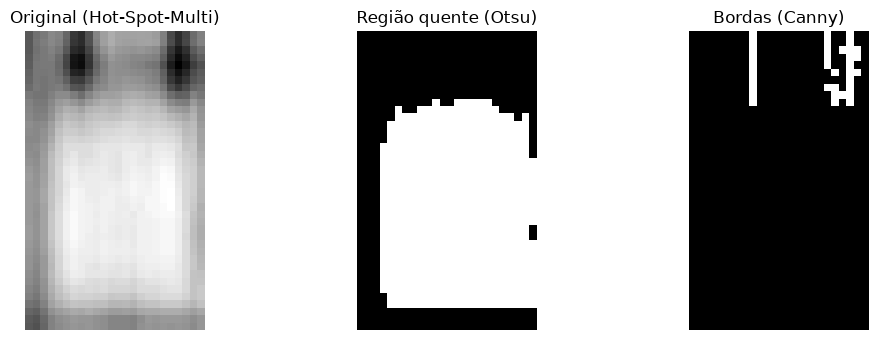

In [6]:
amostra = df[df["anomaly_class"] == "Hot-Spot-Multi"].sample(1, random_state=3).iloc[0]
img_demo = cv2.imread(str(DATA_DIR / amostra["image_filepath"]), cv2.IMREAD_GRAYSCALE)
otsu_t, _ = cv2.threshold(img_demo, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, hot_demo = cv2.threshold(img_demo, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
edges_demo = cv2.Canny(img_demo, 50, 150)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, im, tt in zip(axes, [img_demo, hot_demo, edges_demo],
                      [f"Original ({amostra['anomaly_class']})", "Região quente (Otsu)", "Bordas (Canny)"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(tt)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Extração de todo o dataset

Aplicamos o extrator às 20.000 imagens, obtendo a matriz de características `X_full`
(20000 x 181) e os rótulos `y`. Definimos também um único split de teste (30%, estratificado),
reutilizado em todas as etapas para que os números sejam comparáveis.

In [7]:
registros, y = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros.append(extrair_features(img))
    y.append(row["anomaly_class"])
y = np.array(y)
FEAT_NAMES = list(registros[0].keys())
X_full = np.array([[r[k] for k in FEAT_NAMES] for r in registros])
print(f"Matriz de características: {X_full.shape} | base: {len(BASE_FEATS)} features")

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=42, stratify=y)
y_tr, y_te = y[idx_tr], y[idx_te]
classes = sorted(set(y))
le = LabelEncoder().fit(y)

100%|██████████| 20000/20000 [00:43<00:00, 461.26it/s]


Matriz de características: (20000, 181) | base: 25 features


## 6. Comparação de classificadores (conjunto base de 25 características)

Avaliam-se quatro classificadores de naturezas distintas, todos com tratamento de
desbalanceamento e o mesmo split:

- **Random Forest** — floresta de árvores por agregação (*bagging*).
- **Gradient Boosting** — árvores em sequência, cada uma corrige o erro da anterior.
- **SVM** — fronteira de maior margem entre classes (com normalização).
- **XGBoost** — *gradient boosting* otimizado.

Métrica principal: **F1-score macro** (pesa todas as classes igualmente).

In [9]:
X_base = X_full[:, [FEAT_NAMES.index(c) for c in BASE_FEATS]]
SIGLA = {"RandomForest": "RF", "Gradient Boosting": "GB", "SVM": "SVM", "XGBoost": "XGB"}
ordem_mod = ["RandomForest", "Gradient Boosting", "SVM", "XGBoost"]


def treina_prediz(Xtr, ytr, Xte, nome):
    """Treina o classificador `nome` e devolve as previsões para Xte."""
    if nome == "RandomForest":
        m = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
        m.fit(Xtr, ytr)
        return m.predict(Xte)
    if nome == "Gradient Boosting":
        m = HistGradientBoostingClassifier(random_state=42)
        m.fit(Xtr, ytr, sample_weight=compute_sample_weight("balanced", ytr))
        return m.predict(Xte)
    if nome == "SVM":
        m = make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=42))
        m.fit(Xtr, ytr)
        return m.predict(Xte)
    lo = LabelEncoder().fit(ytr)
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                      random_state=42, n_jobs=-1, eval_metric="mlogloss")
    m.fit(Xtr, lo.transform(ytr), sample_weight=compute_sample_weight("balanced", ytr))
    return lo.inverse_transform(m.predict(Xte))


resumos, prf = [], {}
for n in ordem_mod:
    pred = treina_prediz(X_base[idx_tr], y_tr, X_base[idx_te], n)
    resumos.append({"modelo": SIGLA[n],
                    "acuracia": round(accuracy_score(y_te, pred) * 100, 1),
                    "f1_macro": round(f1_score(y_te, pred, average="macro") * 100, 1)})
    p, r, fa, _ = precision_recall_fscore_support(y_te, pred, labels=classes, zero_division=0)
    prf[SIGLA[n]] = {"P": p * 100, "R": r * 100, "F1": fa * 100}

bench = pd.DataFrame(resumos).set_index("modelo").sort_values("f1_macro", ascending=False)
print("=== Benchmark geral (features base) ===")
print(bench)

=== Benchmark geral (features base) ===
        acuracia  f1_macro
modelo                    
XGB         66.6      42.2
RF          61.9      41.9
GB          54.3      38.5
SVM         42.0      32.9


### F1-score por classe

O detalhe por classe revela onde cada modelo acerta ou falha (classes minoritárias puxam o
F1 macro para baixo).

In [11]:
tab_f1 = pd.DataFrame({s: prf[s]["F1"].round(0) for s in ["RF", "GB", "SVM", "XGB"]}, index=classes)
print(tab_f1)

                  RF    GB   SVM   XGB
Cell            46.0  43.0  40.0  48.0
Cell-Multi      29.0  32.0  22.0  32.0
Cracking        65.0  62.0  63.0  66.0
Diode           61.0  58.0  58.0  67.0
Diode-Multi     28.0  23.0  11.0  20.0
Hot-Spot        18.0  11.0   8.0  10.0
Hot-Spot-Multi  32.0  28.0  14.0  39.0
No-Anomaly      79.0  71.0  56.0  83.0
Offline-Module  36.0  32.0  28.0  38.0
Shadowing       44.0  37.0  37.0  43.0
Soiling         20.0  21.0  19.0  14.0
Vegetation      46.0  43.0  40.0  45.0


Os métodos baseados em árvores (RF e XGBoost) se destacam, com o XGBoost à frente. O F1 macro
ainda modesto motiva enriquecer o conjunto de características.

## 7. Refinamento incremental das características

Partindo do conjunto base (25), grupos de features são adicionados **de forma cumulativa**,
medindo acurácia e F1 macro a cada passo, para RF e XGBoost. A última linha (181 features) é
o conjunto completo. A coluna `d_f1` mostra o ganho de F1 macro sobre a base.

In [12]:
def por_prefixo(prefixos):
    return [n for n in FEAT_NAMES if any(n.startswith(p) for p in prefixos)]


GRUPOS = [
    ("base", []),
    ("+ grade 3x3 + LBP", por_prefixo(["grid_", "lbp_"])),
    ("+ skew/kurtosis", ["skew_int", "kurt_int"]),
    ("+ momentos de Hu", por_prefixo(["hu_"])),
    ("+ Gabor + HOG", por_prefixo(["gabor", "hog_"])),
]


def acc_f1(cols, nome_modelo):
    Xc = X_full[:, [FEAT_NAMES.index(c) for c in cols]]
    pred = treina_prediz(Xc[idx_tr], y_tr, Xc[idx_te], nome_modelo)
    return accuracy_score(y_te, pred) * 100, f1_score(y_te, pred, average="macro") * 100


def incremental(nome_modelo):
    cols, linhas = list(BASE_FEATS), []
    for rotulo, novas in GRUPOS:
        cols = cols + novas
        a, fm = acc_f1(cols, nome_modelo)
        linhas.append({"etapa": rotulo, "n_feat": len(cols), "acuracia": round(a, 1), "f1_macro": round(fm, 1)})
    base_f = linhas[0]["f1_macro"]
    for r in linhas:
        r["d_f1"] = round(r["f1_macro"] - base_f, 1)
    return pd.DataFrame(linhas).set_index("etapa")


tab_rf = incremental("RandomForest")
tab_xgb = incremental("XGBoost")
print("=== Refinamento incremental — Random Forest ===")
print(tab_rf)
print("\n=== Refinamento incremental — XGBoost ===")
print(tab_xgb)

=== Refinamento incremental — Random Forest ===
                   n_feat  acuracia  f1_macro  d_f1
etapa                                              
base                   25      61.9      41.9   0.0
+ grade 3x3 + LBP      44      65.1      43.3   1.4
+ skew/kurtosis        46      64.9      43.5   1.6
+ momentos de Hu       53      65.3      44.3   2.4
+ Gabor + HOG         181      67.8      48.9   7.0

=== Refinamento incremental — XGBoost ===
                   n_feat  acuracia  f1_macro  d_f1
etapa                                              
base                   25      66.6      42.2   0.0
+ grade 3x3 + LBP      44      69.7      45.5   3.3
+ skew/kurtosis        46      70.4      46.6   4.4
+ momentos de Hu       53      70.6      47.6   5.4
+ Gabor + HOG         181      74.2      53.9  11.7


O desempenho cresce de forma consistente a cada grupo, com o maior salto vindo de **Gabor +
HOG**. No XGBoost, o F1 macro sobe de ~42% (base) para ~54% (181 features). Esse conjunto
completo é a base das Partes 2 e 3.